# TimesFM 3.0 PyTorch Inference Demo

This interactive notebook demonstrates zero-shot time series forecasting using **TimesFM 3.0** (PyTorch).

### Key Features Highlighted:
1. **Promotion Example with Dynamic Covariates**: Context length = 2048, Forecast Horizon = 512 with dynamic past-future promotion indicator.
2. **Synthetic Curves (Horizon > 64)**: Evaluating long horizons across sine waves and linear trend extrapolation.
3. **GPU Acceleration**: Automatic CUDA inference with quantile uncertainty intervals.

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from timesfm3 import TimesFM3Forecaster

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


/home/dskim/fork/timesfm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.14.0+cu130
CUDA available: True


## 2. Initialize TimesFM 3.0 Forecaster

We instantiate `TimesFM3Forecaster` from the default Hugging Face pretrained checkpoint (`google/timesfm-3.0-pytorch`).


In [2]:
# Load TimesFM 3.0 directly from Hugging Face Hub (default: "google/timesfm-3.0-pytorch")
forecaster = TimesFM3Forecaster.from_pretrained(
    "google/timesfm-3.0-pytorch",
    per_core_batch_size=4,
    device="cpu",  # <--- 이 줄을 추가합니다.
)

print(f"TimesFM3 forecaster loaded successfully on device: {forecaster.device}")


TimesFM3 forecaster loaded successfully on device: cpu


## 3. Scenario 1: Promotion Example with Dynamic Covariates

- **Context Length**: 2048
- **Forecast Horizon**: 512
- **Past-Future Covariates**: Binary promotion covariate (0 or 1) spanning the full length (2560 steps).
- **Target Multiplier**: Target value is boosted by 5x during active promotions.

In [3]:
context_len = 2048
horizon_len = 512
total_len = context_len + horizon_len
time = np.arange(total_len)

# Generate promotion indicator
promotions = np.zeros(total_len, dtype=np.float32)
# Promotion in context
promotions[1130:1180] = 1.0
# Promotions in forecast horizon
promotions[2250:2290] = 1.0
promotions[2320:2355] = 1.0

pfc_np = np.array([promotions], dtype=np.float32)

# Generate base target: periodic sine + noise
base_target = 2.0 + np.sin(time / 20.0) + np.random.randn(total_len) * 0.15
# Apply 5x promo boost
target_full = (base_target * np.where(promotions == 1.0, 5.0, 1.0)).astype(np.float32)

context = target_full[:context_len]
actual_horizon = target_full[context_len:]

print(f"Context shape: {context.shape}")
print(f"Horizon length: {horizon_len}")
print(f"Past-Future Covariates shape: {pfc_np.shape}")

Context shape: (2048,)
Horizon length: 512
Past-Future Covariates shape: (1, 2560)


In [4]:
# Run zero-shot forecast with dynamic past-future covariates
torch_out = forecaster.predict(
    context=context,
    horizon=horizon_len,
    past_future_covariates=pfc_np,
    return_quantiles=True,
)

print("Forecast generated successfully!")
print(f"Point forecast shape: {torch_out.forecast.shape}")
print(f"Quantiles shape: {torch_out.quantiles.shape}")

Forecast generated successfully!
Point forecast shape: (512,)
Quantiles shape: (512, 9)


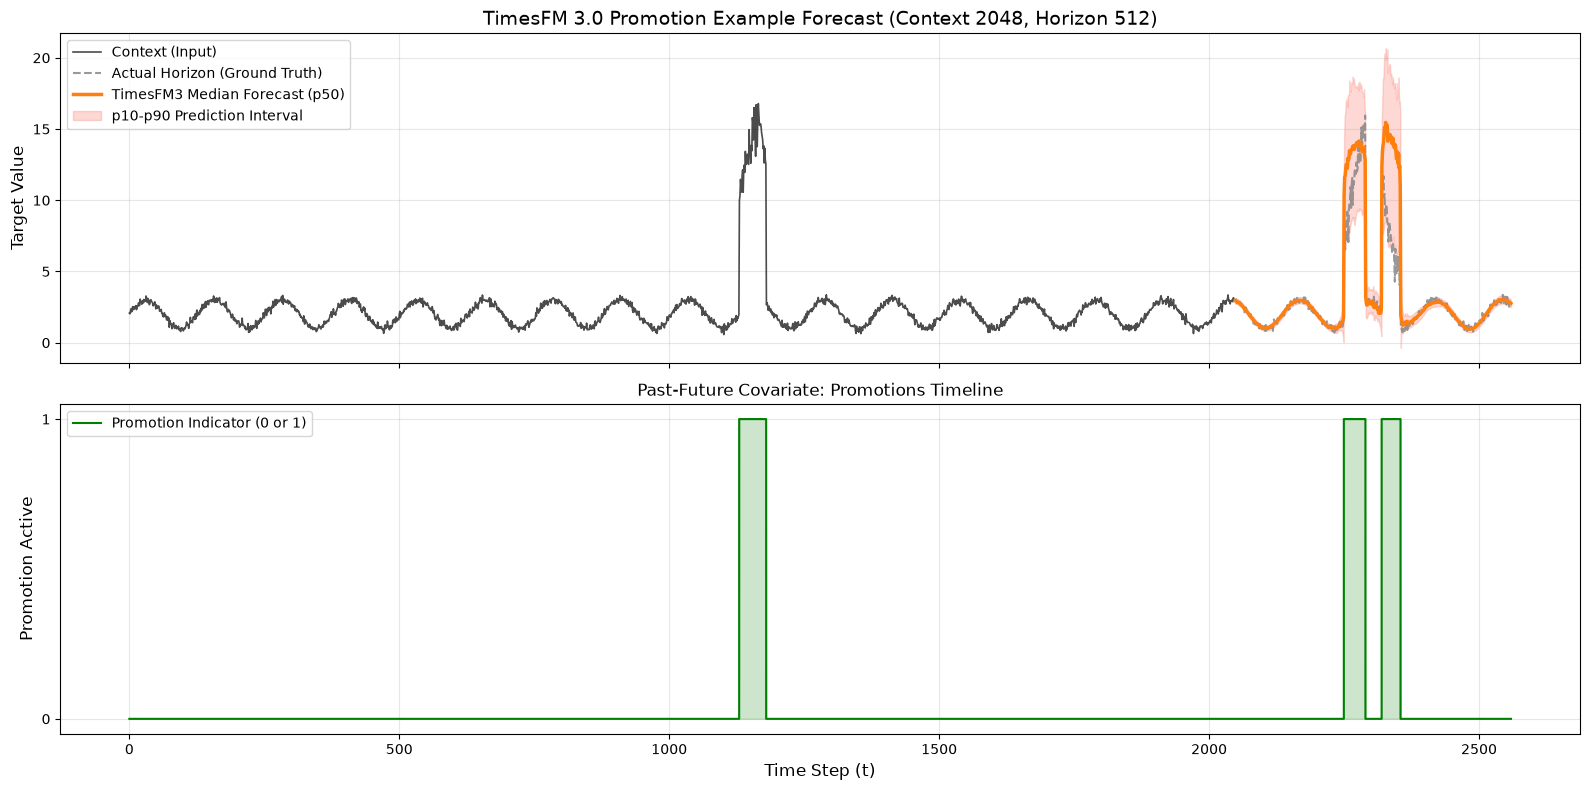

In [5]:
# Plot Promotion Example
time_context = np.arange(context_len)
time_horizon = np.arange(context_len, total_len)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Subplot 0: Target, Actual Horizon, and PyTorch Forecast
axes[0].plot(time_context, context, label="Context (Input)", color="black", alpha=0.7, linewidth=1.2)
axes[0].plot(time_horizon, actual_horizon, label="Actual Horizon (Ground Truth)", linestyle="--", color="gray", alpha=0.8)
axes[0].plot(time_horizon, torch_out.forecast, label="TimesFM3 Median Forecast (p50)", color="#ff7f0e", linewidth=2.5)
if torch_out.quantiles is not None:
    axes[0].fill_between(
        time_horizon,
        torch_out.quantiles[:, 0],
        torch_out.quantiles[:, -1],
        color="salmon",
        alpha=0.3,
        label="p10-p90 Prediction Interval",
    )
axes[0].set_title("TimesFM 3.0 Promotion Example Forecast (Context 2048, Horizon 512)", fontsize=14)
axes[0].set_ylabel("Target Value", fontsize=12)
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Subplot 1: Past-Future Promotion Covariate
axes[1].plot(time, promotions, label="Promotion Indicator (0 or 1)", color="green", drawstyle="steps-mid", linewidth=1.5)
axes[1].fill_between(time, 0, promotions, color="green", alpha=0.2)
axes[1].set_title("Past-Future Covariate: Promotions Timeline", fontsize=12)
axes[1].set_ylabel("Promotion Active", fontsize=12)
axes[1].set_xlabel("Time Step (t)", fontsize=12)
axes[1].set_yticks([0, 1])
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Scenario 2: Long Horizon Synthetic Curves (Horizon 128 > 64)

Evaluates rolling patch autoregressive decoding across:
1. **Sine Curve** (periodic continuation)
2. **Linear Trend** (linear detrending extrapolation)

In [6]:
synth_context_len = 256
synth_horizon_len = 128
synth_total_len = synth_context_len + synth_horizon_len
t_synth = np.linspace(0, 8 * np.pi, synth_total_len, dtype=np.float32)

# Series 0: Sine wave
s_sine = np.sin(t_synth)
# Series 1: Linear trend line
s_line = np.arange(synth_total_len, dtype=np.float32) * 0.05 + 2.0

contexts = [s_sine[:synth_context_len], s_line[:synth_context_len]]
ground_truths = [s_sine[synth_context_len:], s_line[synth_context_len:]]

# Batch predict
synth_outputs = list(forecaster.predict_batch(contexts, horizon=synth_horizon_len))

# Compute metrics
sine_mae = np.mean(np.abs(synth_outputs[0].forecast - ground_truths[0]))
line_mae = np.mean(np.abs(synth_outputs[1].forecast - ground_truths[1]))

print(f"Sine Curve Mean Absolute Error: {sine_mae:.6f}")
print(f"Linear Trend Mean Absolute Error: {line_mae:.6f}")

Sine Curve Mean Absolute Error: 0.012575
Linear Trend Mean Absolute Error: 0.000000


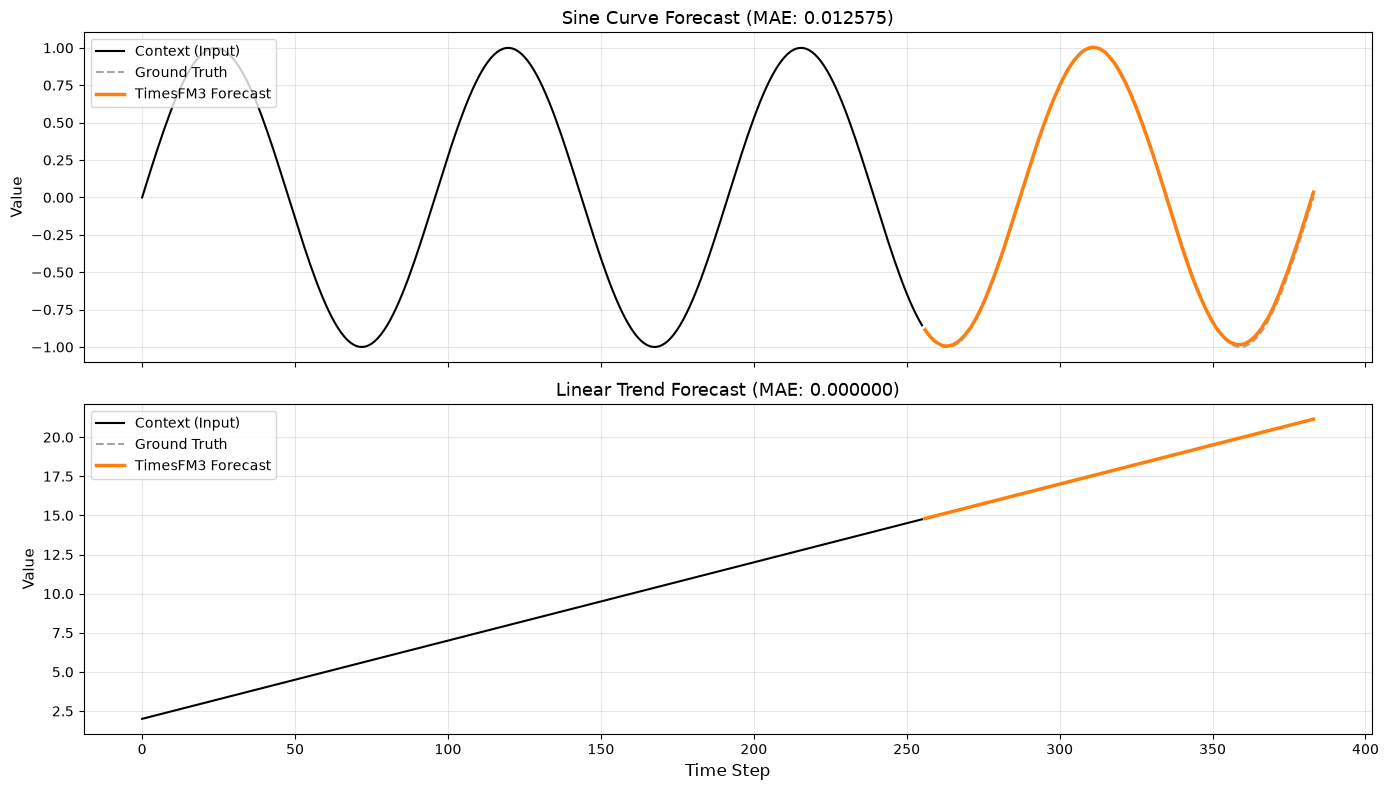

In [7]:
# Plot Synthetic Curves
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
t_ctx = np.arange(synth_context_len)
t_hor = np.arange(synth_context_len, synth_total_len)
titles = [
    f"Sine Curve Forecast (MAE: {sine_mae:.6f})",
    f"Linear Trend Forecast (MAE: {line_mae:.6f})",
]

for i, ax in enumerate(axes):
    ax.plot(t_ctx, contexts[i], label="Context (Input)", color="black", linewidth=1.5)
    ax.plot(t_hor, ground_truths[i], label="Ground Truth", color="gray", linestyle="--", alpha=0.7)
    ax.plot(t_hor, synth_outputs[i].forecast, label="TimesFM3 Forecast", color="#ff7f0e", linewidth=2.5)
    ax.set_title(titles[i], fontsize=13)
    ax.set_ylabel("Value", fontsize=11)
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel("Time Step", fontsize=12)
plt.tight_layout()
plt.show()